In [1]:
import numpy as np
import pymc as pm
import arviz as az
# -- use this line at the beginning of your notebook to turn on interactive plots
%matplotlib notebook
import scipy.io
# note these imports, thay may be useful in your own task

import matplotlib.pyplot as plt  # plotting library
import numpy as np  # work with numeric arrays without labeled axes
import xarray as xr  # work with arrays with labeled axes
import pandas as pd

In [2]:
file_path = 'LH_metal_DB_v1.12.csv'  # 替换为你的文件路径
df = pd.read_csv(file_path)
df.loc[:, 'TOK'] = df['TOK'].str.strip()
df['IP']=df['IP'].abs()/1000000
df['BT']=df['BT'].abs()
df['PLTH']=df['PLTH']/1000000
df['NEL']=df['NEL']/1e19

In [3]:



# 1. 筛选 TOK 为 'JET' 的子集，并获取 DIVCON 列的独特字符串
subset = df[df['TOK'] == 'JET']
unique_divcon = subset['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    df[divcon_type] = (df['DIVCON'] == divcon_type).astype(int)

# 打印结果以验证
print(df.iloc[588])


TOK               JET
SHOT            85960
TIME            54.49
PHASE              LH
PGASA            1.95
RGEO          2.88281
AMIN         0.956482
KAPPA         1.62546
SPLASMA       139.131
CONFIG          SN(B)
IGRADB              1
WALMAT             Be
DIVMAT              W
LIMMAT             Be
EVAP             NONE
BT            2.39848
IP            1.95784
Q95             3.771
NEL              3.36
ZEFF                -
DIVNAME       MkII-HD
PL            3488720
PLTH          3.48872
PFLOSS            0.0
PRADCORE       615366
DIVCON             V5
FRACNMIN          0.0
LHTIME          54.52
AUXHEAT            IC
SELEC2024           1
V5                  1
CORNER              0
VT                  0
V5L                 0
V5E                 0
V5C                 0
HT3R                0
HT3L                0
HT3                 0
Name: 588, dtype: object


In [4]:


# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK', 'SPLASMA','BT','IP','RGEO','PLTH','NEL','PGASA',"DIVCON"]
one_hot_columns=['V5','CORNER','VT','V5L','V5E','V5C','HT3R','HT3L','HT3']
new_df = df[df['SELEC2024'] == 1][columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))

new_df['PLTH/S/2']=new_df['PLTH']/new_df['SPLASMA']/2
# 显示新 DataFrame
print("New DataFrame:")
print(new_df)



New DataFrame:
      TOK    SPLASMA       BT        IP      RGEO     PLTH    NEL  PGASA  \
0    CMOD    7.42158  5.33923  0.931812  0.672389  2.28952  19.70  2.000   
2    CMOD    7.37796  5.32586  0.634247  0.672785  1.42493  18.90  2.000   
3    CMOD    7.43647  5.33346  1.030660  0.670869  1.37273  16.20  2.000   
4    CMOD    6.70529  5.26510  0.681653  0.678764  1.79110  22.00  2.000   
5    CMOD    6.70899  5.26576  0.660100  0.678854  1.81159  21.50  2.000   
..    ...        ...      ...       ...       ...      ...    ...    ...   
679   JET  138.89300  2.94982  2.466400  2.900350  7.87774   3.65  1.922   
680   JET  138.67000  2.93182  3.154820  2.908120  7.33348   3.28  1.925   
683   JET  138.41700  2.95200  2.168050  2.898780  7.39600   3.22  1.915   
684   JET  138.57200  2.94335  2.806420  2.904780  9.08634   3.26  1.904   
686   JET  138.53000  3.31544  2.467660  2.901440  8.96516   3.37  1.916   

       DIVCON        BP  PLTH/S/2  
0     VERTPLT  0.666565  0.154247  


In [5]:
# 1. 筛选 TOK 为 'JET' 的子集，并获取 DIVCON 列的独特字符串
subset = new_df[new_df['TOK'] == 'JET']
unique_divcon = subset['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)

In [6]:
subset1 = new_df[new_df['TOK'] == 'CMOD']
subset2 = new_df[new_df['TOK'] == 'AUG']
subset3 = new_df[new_df['TOK'] == 'JET']

In [7]:
print(new_df)

      TOK    SPLASMA       BT        IP      RGEO     PLTH    NEL  PGASA  \
0    CMOD    7.42158  5.33923  0.931812  0.672389  2.28952  19.70  2.000   
2    CMOD    7.37796  5.32586  0.634247  0.672785  1.42493  18.90  2.000   
3    CMOD    7.43647  5.33346  1.030660  0.670869  1.37273  16.20  2.000   
4    CMOD    6.70529  5.26510  0.681653  0.678764  1.79110  22.00  2.000   
5    CMOD    6.70899  5.26576  0.660100  0.678854  1.81159  21.50  2.000   
..    ...        ...      ...       ...       ...      ...    ...    ...   
679   JET  138.89300  2.94982  2.466400  2.900350  7.87774   3.65  1.922   
680   JET  138.67000  2.93182  3.154820  2.908120  7.33348   3.28  1.925   
683   JET  138.41700  2.95200  2.168050  2.898780  7.39600   3.22  1.915   
684   JET  138.57200  2.94335  2.806420  2.904780  9.08634   3.26  1.904   
686   JET  138.53000  3.31544  2.467660  2.901440  8.96516   3.37  1.916   

       DIVCON        BP  PLTH/S/2  V5  CORNER  VT  V5L  V5E  V5C  HT3R  
0     VERTPLT 

# 先用传统环向磁场尝试，发现还是BP可能好一点

In [8]:
columns_to_include_for_regre = ['BT','PLTH/S/2','NEL']

In [9]:
CMOD_df = subset1[columns_to_include_for_regre].copy()
CMOD_df = CMOD_df.apply(np.log)
x = CMOD_df[['BT','NEL']]  # 自变量列
y=CMOD_df["PLTH/S/2"]


decision coefficient R²: 0.5634522579034704
RMSE: 0.17960022074037382
regression coe: [-0.14407301  1.2106796 ]
intercept: -5.225573995231096


<IPython.core.display.Javascript object>


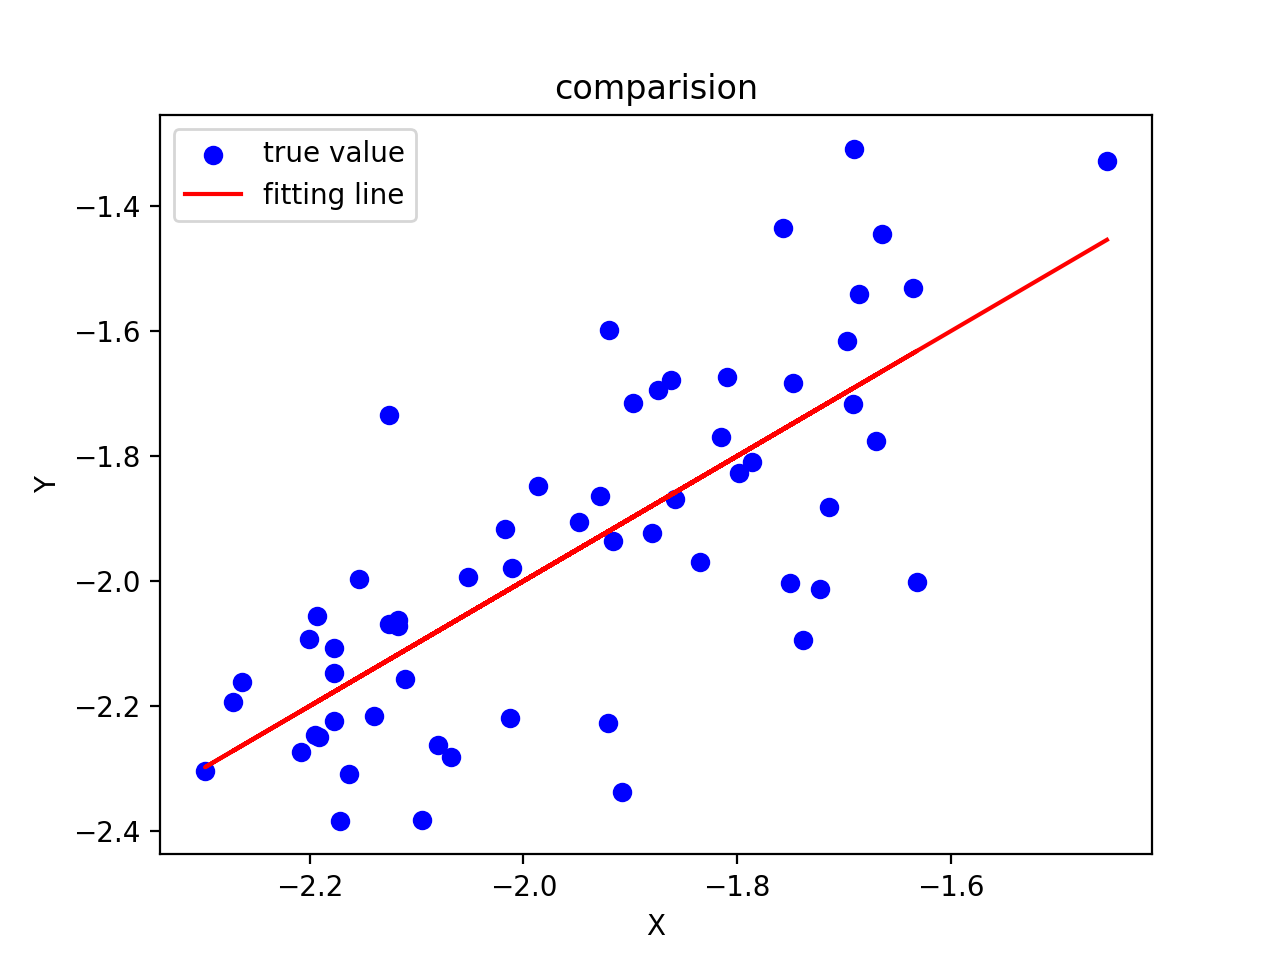

Intercept: -5.226 ± 0.479
Coefficient 1: -0.144 ± 0.131
Coefficient 2: 1.211 ± 0.140


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
model = LinearRegression()


model.fit(x, y)
y_pred = model.predict(x)
r2 = r2_score(y, y_pred)
rss = mean_squared_error(y, y_pred) * len(y)  # 计算 RSS
mse = rss / len(y)  # 计算未修正的 MSE
rmse = np.sqrt(mse) 
print(f"decision coefficient R²: {r2}")
print(f"RMSE: {rmse}")
print("regression coe:", model.coef_)
print("intercept:", model.intercept_)
from mpl_toolkits.mplot3d import Axes3D
y_pred = model.predict(x)
plt.figure()
plt.scatter(y_pred, y, color='blue', label='true value')
plt.plot(y_pred, y_pred, color='red', label='fitting line')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('comparision')
plt.show()

X_with_intercept = np.hstack([np.ones((x.shape[0], 1)), x])
XTX_inv = np.linalg.inv(X_with_intercept.T.dot(X_with_intercept))


se = np.sqrt(np.diagonal(mse * XTX_inv))


coefficients = np.append(model.intercept_, model.coef_)
labels = ['Intercept'] + [f'Coefficient {i+1}' for i in range(len(model.coef_))]

for label, coef, std_err in zip(labels, coefficients, se):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

# AUG的

In [11]:
columns_to_include_for_regre = ['BT','PLTH/S/2','NEL','PGASA']

decision coefficient R²: 0.814192197375003
RMSE: 0.13256630698183944
regression coe: [ 0.63444761  0.89557856 -0.91643623]
intercept: -5.477057951439363


<IPython.core.display.Javascript object>


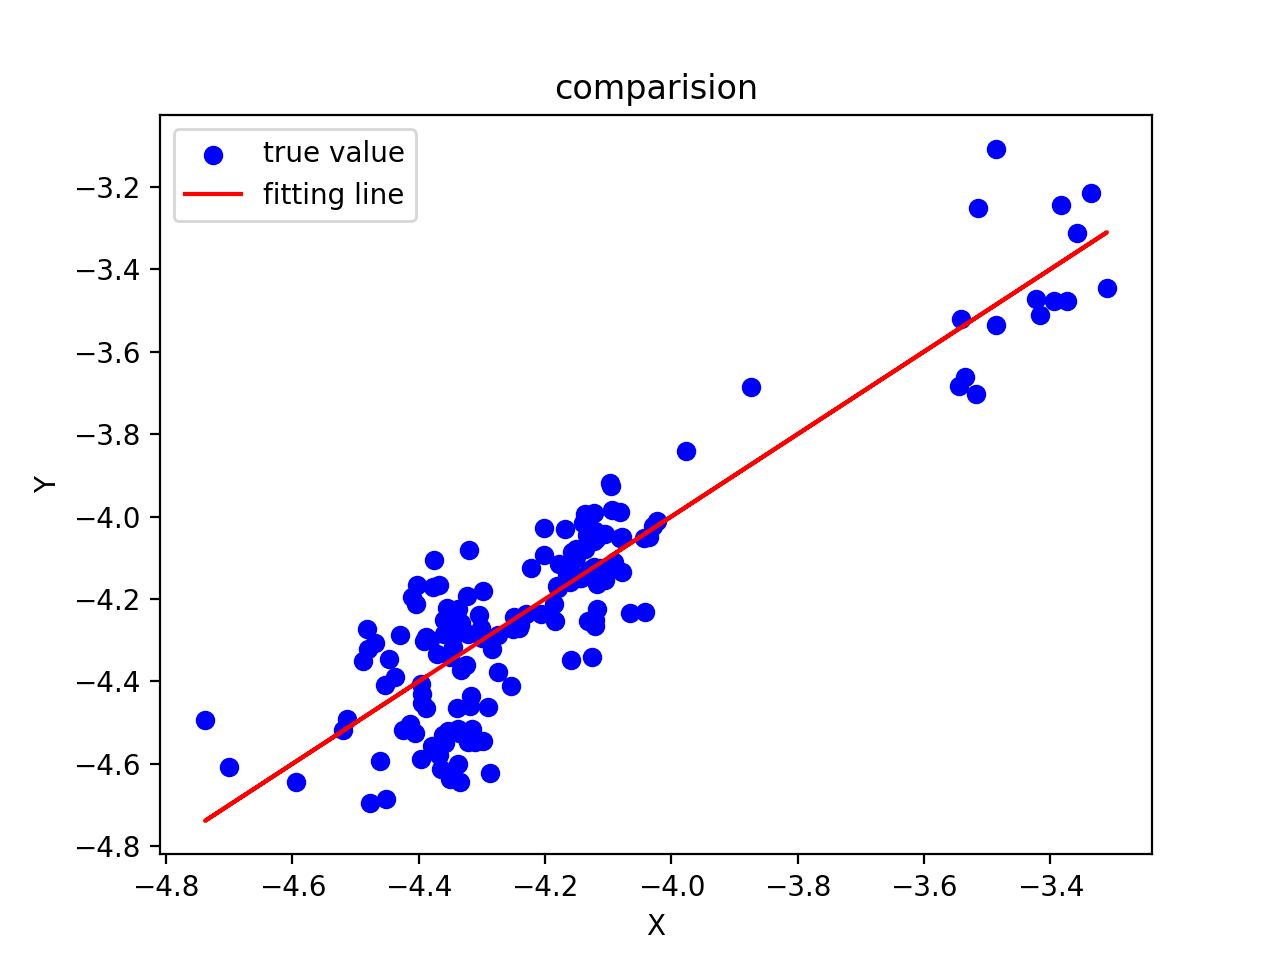

Intercept: -5.477 ± 0.159
Coefficient 1: 0.634 ± 0.105
Coefficient 2: 0.896 ± 0.074
Coefficient 3: -0.916 ± 0.056


In [12]:
AUG_df = subset2[columns_to_include_for_regre].copy()
AUG_df = AUG_df.apply(np.log)
x = AUG_df[['BT','NEL','PGASA']]  # 自变量列
y=AUG_df["PLTH/S/2"]
model2 = LinearRegression()

# 拟合模型
model2.fit(x, y)
y_pred = model2.predict(x)
r2 = r2_score(y, y_pred)
rss = mean_squared_error(y, y_pred) * len(y)  # 计算 RSS
mse = rss / len(y)  # 计算未修正的 MSE
rmse = np.sqrt(mse) 
print(f"decision coefficient R²: {r2}")
print(f"RMSE: {rmse}")
print("regression coe:", model2.coef_)
print("intercept:", model2.intercept_)

y_pred = model2.predict(x)
plt.figure()
plt.scatter(y_pred, y, color='blue', label='true value')
plt.plot(y_pred, y_pred, color='red', label='fitting line')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('comparision')
plt.show()
# 计算 X 的转置乘以 X，注意这里我们要为 X 矩阵添加一列全为 1 的列来代表截距
X_with_intercept = np.hstack([np.ones((x.shape[0], 1)), x])
XTX_inv = np.linalg.inv(X_with_intercept.T.dot(X_with_intercept))

# 计算系数的标准误差，包括截距
se = np.sqrt(np.diagonal(mse * XTX_inv))

# 打印截距及其误差，以及其他系数及其误差
coefficients = np.append(model2.intercept_, model2.coef_)
labels = ['Intercept'] + [f'Coefficient {i+1}' for i in range(len(model2.coef_))]

for label, coef, std_err in zip(labels, coefficients, se):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

In [15]:
import pandas as pd

# 假设 df 是您的 DataFrame

# 检查每一行是否所有元素都为0
rows_all_zeros = (new_df == 0).all(axis=1)

# 查看含有全0的行
zero_rows = new_df[rows_all_zeros]

# 打印出这些行
print(zero_rows)

# 检查并反馈是否存在这样的行
if zero_rows.empty:
    print("没有任何行全部为0。")
else:
    print("存在一行或多行全部为0。")


Empty DataFrame
Columns: [TOK, SPLASMA, BT, IP, RGEO, PLTH, NEL, PGASA, DIVCON, BP, PLTH/S/2, V5, CORNER, VT, V5L, V5E, V5C, HT3R]
Index: []
没有任何行全部为0。


In [16]:
one_hot_columns2=['V5', 'CORNER', 'VT', 'V5L', 'V5E', 'V5C', 'HT3R']

In [17]:
subset3

,TOK,SPLASMA,BT,IP,RGEO,PLTH,NEL,PGASA,DIVCON,BP,PLTH/S/2,V5,CORNER,VT,V5L,V5E,V5C,HT3R
329,JET,138.948,1.79605,1.64845,2.87944,1.51043,2.31,1.994,V5,0.269725,0.005435,1,0,0,0,0,0,0
330,JET,141.637,3.68480,3.94234,2.87353,12.20250,5.26,1.918,CORNER,0.631514,0.043077,0,1,0,0,0,0,0
331,JET,140.905,1.28971,1.35890,2.85668,1.87274,1.92,1.953,CORNER,0.217527,0.006645,0,1,0,0,0,0,0
332,JET,141.642,1.91676,2.06529,2.86533,3.72168,2.40,1.917,CORNER,0.329878,0.013138,0,1,0,0,0,0,0
333,JET,142.006,3.22555,3.44277,2.88515,9.03347,3.15,1.888,CORNER,0.552280,0.031807,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
679,JET,138.893,2.94982,2.46640,2.90035,7.87774,3.65,1.922,CORNER,0.406652,0.028359,0,1,0,0,0,0,0
680,JET,138.670,2.93182,3.15482,2.90812,7.33348,3.28,1.925,CORNER,0.522389,0.026442,0,1,0,0,0,0,0
683,JET,138.417,2.95200,2.16805,2.89878,7.39600,3.22,1.915,CORNER,0.358496,0.026716,0,1,0,0,0,0,0
684,JET,138.572,2.94335,2.80642,2.90478,9.08634,3.26,1.904,CORNER,0.464494,0.032786,0,1,0,0,0,0,0


# JET的

           BT       NEL     PGASA  VT
329  0.585590  0.837248  0.690143   0
330  1.304216  1.660131  0.651283   1
331  0.254417  0.652325  0.669367   1
332  0.650636  0.875469  0.650761   1
333  1.171103  1.147402  0.635518   1
..        ...       ...       ...  ..
679  1.081744  1.294727  0.653366   1
680  1.075623  1.187843  0.654926   1
683  1.082483  1.169381  0.649718   1
684  1.079548  1.181727  0.643957   1
686  1.198590  1.214913  0.650240   1

[262 rows x 4 columns]
           BT       NEL     PGASA  VT
329  0.585590  0.837248  0.690143   0
330  1.304216  1.660131  0.651283   1
331  0.254417  0.652325  0.669367   1
332  0.650636  0.875469  0.650761   1
333  1.171103  1.147402  0.635518   1
..        ...       ...       ...  ..
679  1.081744  1.294727  0.653366   1
680  1.075623  1.187843  0.654926   1
683  1.082483  1.169381  0.649718   1
684  1.079548  1.181727  0.643957   1
686  1.198590  1.214913  0.650240   1

[262 rows x 4 columns]
decision coefficient R²: 0.8882222540929

<IPython.core.display.Javascript object>


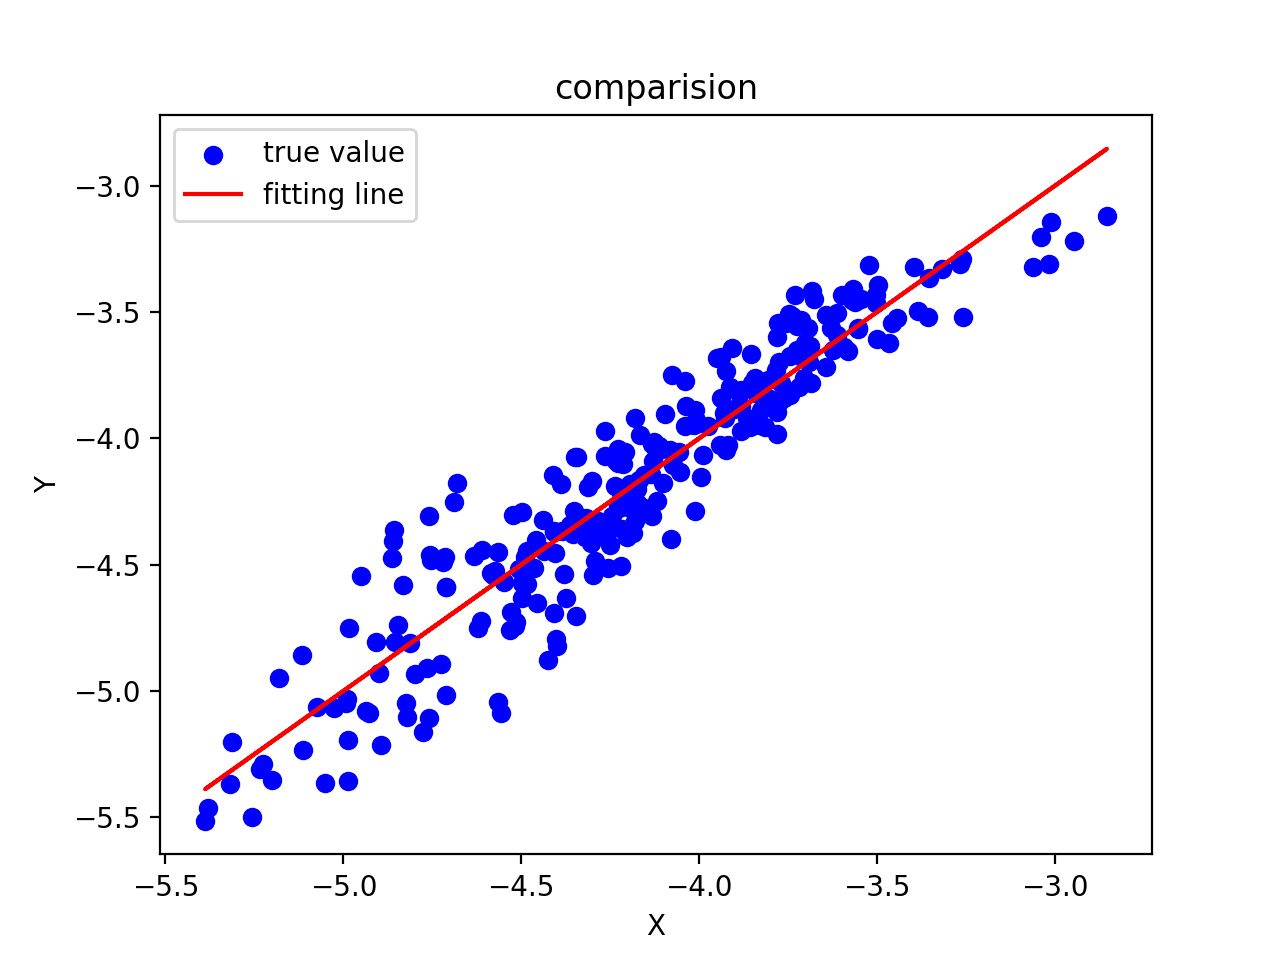

Intercept: -5.435 ± 0.059
Coefficient 1: 0.431 ± 0.059
Coefficient 2: 1.220 ± 0.052
Coefficient 3: -1.060 ± 0.042
Coefficient 4: 0.527 ± 0.026


In [18]:
JET_df = subset3[columns_to_include_for_regre].copy()
JET_df = JET_df.apply(np.log)
x = JET_df[['BT','NEL','PGASA']] 
x[one_hot_columns2] = new_df[new_df['TOK'] == 'JET'][one_hot_columns2]
#x['VT'] = x[['V5', 'VT', 'V5L', 'V5E', 'V5C','CORNER']].max(axis=1)
x['VT'] = x[['VT','CORNER']].max(axis=1)
x.drop(['V5', 'V5L', 'V5E', 'V5C','CORNER'], axis=1, inplace=True)

x.drop(['HT3R'], axis=1, inplace=True)
print(x)
y=JET_df["PLTH/S/2"]
model3 = LinearRegression()
print(x)
# 拟合模型
model3.fit(x, y)
y_pred = model3.predict(x)
r2 = r2_score(y, y_pred)
rss = mean_squared_error(y, y_pred) * len(y)
mse = rss / (len(y) - len(model3.coef_) - 1)
print(f"decision coefficient R²: {r2}")
print(f"RMSE: {np.sqrt(mse)}")
print("regression coe:", model3.coef_)
print("intercept:", model3.intercept_)

y_pred = model3.predict(x)
plt.figure()
plt.scatter(y_pred, y, color='blue', label='true value')
plt.plot(y_pred, y_pred, color='red', label='fitting line')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('comparision')
plt.show()
# 计算 X 的转置乘以 X，注意这里我们要为 X 矩阵添加一列全为 1 的列来代表截距
X_with_intercept = np.hstack([np.ones((x.shape[0], 1)), x])
XTX_inv = np.linalg.inv(X_with_intercept.T.dot(X_with_intercept))

# 计算系数的标准误差，包括截距
se = np.sqrt(np.diagonal(mse * XTX_inv))

# 打印截距及其误差，以及其他系数及其误差
coefficients = np.append(model3.intercept_, model3.coef_)
labels = ['Intercept'] + [f'Coefficient {i+1}' for i in range(len(model3.coef_))]

for label, coef, std_err in zip(labels, coefficients, se):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

# 使用不同的D矩阵

           BT       NEL     PGASA  CORNER  VT  V5L  V5E  V5C
329  0.585590  0.837248  0.690143       0   0    0    0    0
330  1.304216  1.660131  0.651283       1   0    0    0    0
331  0.254417  0.652325  0.669367       1   0    0    0    0
332  0.650636  0.875469  0.650761       1   0    0    0    0
333  1.171103  1.147402  0.635518       1   0    0    0    0
..        ...       ...       ...     ...  ..  ...  ...  ...
679  1.081744  1.294727  0.653366       1   0    0    0    0
680  1.075623  1.187843  0.654926       1   0    0    0    0
683  1.082483  1.169381  0.649718       1   0    0    0    0
684  1.079548  1.181727  0.643957       1   0    0    0    0
686  1.198590  1.214913  0.650240       1   0    0    0    0

[262 rows x 8 columns]
           BT       NEL     PGASA  CORNER  VT  V5L  V5E  V5C
329  0.585590  0.837248  0.690143       0   0    0    0    0
330  1.304216  1.660131  0.651283       1   0    0    0    0
331  0.254417  0.652325  0.669367       1   0    0    0    0


<IPython.core.display.Javascript object>


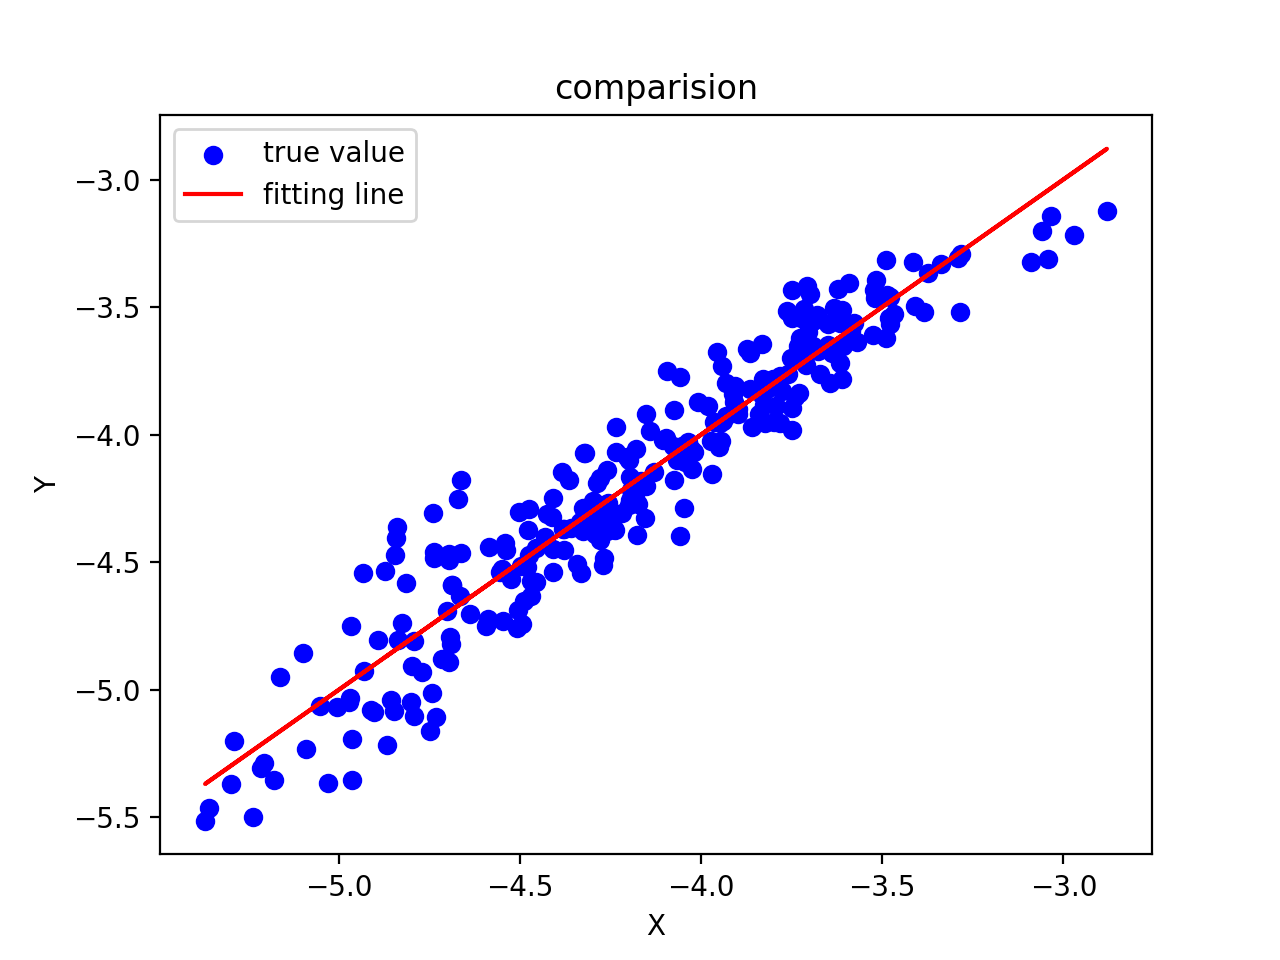

Intercept: -5.403 ± 0.054
Coefficient 1: 0.443 ± 0.055
Coefficient 2: 1.216 ± 0.048
Coefficient 3: -1.076 ± 0.038
Coefficient 4: 0.473 ± 0.026
Coefficient 5: 0.575 ± 0.041
Coefficient 6: -0.318 ± 0.048
Coefficient 7: -0.151 ± 0.084
Coefficient 8: 0.123 ± 0.118


In [21]:
JET_df = subset3[columns_to_include_for_regre].copy()
JET_df = JET_df.apply(np.log)
x = JET_df[['BT','NEL','PGASA']] 
x[one_hot_columns2] = df[df['TOK'] == 'JET'][one_hot_columns2]
#x['VT'] = x[['V5', 'VT', 'V5L', 'V5E', 'V5C','CORNER']].max(axis=1)
#x['VT'] = x[['VT','CORNER']].max(axis=1)
#x.drop(['V5', 'V5L', 'V5E', 'V5C','CORNER'], axis=1, inplace=True)

x.drop(['HT3R'], axis=1, inplace=True)
print(x)
y=JET_df["PLTH/S/2"]
model3 = LinearRegression()
print(x)
# 拟合模型
model3.fit(x, y)
y_pred = model3.predict(x)
r2 = r2_score(y, y_pred)
rss = mean_squared_error(y, y_pred) * len(y)
mse = rss / (len(y) - len(model3.coef_) - 1)
print(f"decision coefficient R²: {r2}")
print(f"RMSE: {np.sqrt(mse)}")
print("regression coe:", model3.coef_)
print("intercept:", model3.intercept_)

y_pred = model3.predict(x)
plt.figure()
plt.scatter(y_pred, y, color='blue', label='true value')
plt.plot(y_pred, y_pred, color='red', label='fitting line')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('comparision')
plt.show()
# 计算 X 的转置乘以 X，注意这里我们要为 X 矩阵添加一列全为 1 的列来代表截距
X_with_intercept = np.hstack([np.ones((x.shape[0], 1)), x])
XTX_inv = np.linalg.inv(X_with_intercept.T.dot(X_with_intercept))

# 计算系数的标准误差，包括截距
se = np.sqrt(np.diagonal(mse * XTX_inv))

# 打印截距及其误差，以及其他系数及其误差
coefficients = np.append(model3.intercept_, model3.coef_)
labels = ['Intercept'] + [f'Coefficient {i+1}' for i in range(len(model3.coef_))]

for label, coef, std_err in zip(labels, coefficients, se):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

In [22]:
import statsmodels.api as sm
X_with_intercept = sm.add_constant(x)
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

                            OLS Regression Results                            
Dep. Variable:               PLTH/S/2   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                     311.6
Date:                Mon, 20 Jan 2025   Prob (F-statistic):          2.63e-126
Time:                        14:27:33   Log-Likelihood:                 103.81
No. Observations:                 262   AIC:                            -189.6
Df Residuals:                     253   BIC:                            -157.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.4030      0.054    -99.475      0.0

# 发现包括HT3R的话会奇异

In [84]:
import statsmodels.api as sm
JET_df = subset3[columns_to_include_for_regre].copy()
JET_df = JET_df.apply(np.log)
x = JET_df[['BT','NEL','PGASA']] 
x[one_hot_columns2] = new_df[new_df['TOK'] == 'JET'][one_hot_columns2]
x.drop(['V5C','V5E','HT3R'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

                            OLS Regression Results                            
Dep. Variable:               PLTH/S/2   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     350.9
Date:                Thu, 09 Jan 2025   Prob (F-statistic):          1.18e-126
Time:                        21:05:37   Log-Likelihood:                 101.56
No. Observations:                 262   AIC:                            -187.1
Df Residuals:                     254   BIC:                            -158.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3944      0.080    -67.675      0.0

# 多机数据

In [155]:

unique_divcon = new_df['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['BT','NEL','PGASA']] 
x[unique_divcon] = new_df[unique_divcon]

In [156]:
# 分析各个独热编码的数量
one_hot_counts = x.sum()
print(one_hot_counts)


BT          458.767215
NEL         714.560232
PGASA       312.445283
 VERTPLT     59.000000
STANDARD    141.000000
Xptref        8.000000
Xpthigh       9.000000
Xptin         4.000000
V5          153.000000
CORNER       66.000000
VT           21.000000
V5L          13.000000
V5E           4.000000
V5C           2.000000
HT3R          3.000000
dtype: float64


In [157]:

x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop([' VERTPLT','V5'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
#x['hor'] = x[['V5E','V5C','HT3R']].max(axis=1)
x.drop(['V5E','V5C','HT3R'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["PLTH/S/2"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

                            OLS Regression Results                            
Dep. Variable:               PLTH/S/2   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     1564.
Date:                Fri, 10 Jan 2025   Prob (F-statistic):               0.00
Time:                        07:41:19   Log-Likelihood:                 189.43
No. Observations:                 483   AIC:                            -360.9
Df Residuals:                     474   BIC:                            -323.2
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3400      0.034   -158.314      0.0

# 现在使用电流

In [162]:
columns_to_include_for_regre_IP=['IP', 'PLTH/S/2', 'NEL', 'PGASA']
multi_df = new_df[columns_to_include_for_regre_IP].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['IP','NEL','PGASA']] 
x[unique_divcon] = new_df[unique_divcon]
x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop([' VERTPLT','V5'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
#x['hor'] = x[['V5E','V5C','HT3R']].max(axis=1)
x.drop(['V5E','V5C','HT3R'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["PLTH/S/2"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

                            OLS Regression Results                            
Dep. Variable:               PLTH/S/2   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     1408.
Date:                Fri, 10 Jan 2025   Prob (F-statistic):               0.00
Time:                        07:54:22   Log-Likelihood:                 165.12
No. Observations:                 483   AIC:                            -312.2
Df Residuals:                     474   BIC:                            -274.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.4658      0.044   -124.181      0.0

# 电流和磁场一起使用

In [165]:
columns_to_include_for_regre_IP=['IP','BT', 'PLTH/S/2', 'NEL', 'PGASA']
multi_df = new_df[columns_to_include_for_regre_IP].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['IP','BT','NEL','PGASA']] 
x[unique_divcon] = new_df[unique_divcon]
x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop([' VERTPLT','V5'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
#x['hor'] = x[['V5E','V5C','HT3R']].max(axis=1)
x.drop(['V5E','V5C','HT3R'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["PLTH/S/2"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

                            OLS Regression Results                            
Dep. Variable:               PLTH/S/2   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     1436.
Date:                Fri, 10 Jan 2025   Prob (F-statistic):               0.00
Time:                        08:10:37   Log-Likelihood:                 197.51
No. Observations:                 483   AIC:                            -375.0
Df Residuals:                     473   BIC:                            -333.2
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.4387      0.041   -131.577      0.0

# 现在使用环向磁场

In [167]:
columns_to_include_for_regre_IP=['IP','BP', 'PLTH/S/2', 'NEL', 'PGASA']
multi_df = new_df[columns_to_include_for_regre_IP].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['IP','BP','NEL','PGASA']] 
x[unique_divcon] = new_df[unique_divcon]
x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop([' VERTPLT','V5'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
#x['hor'] = x[['V5E','V5C','HT3R']].max(axis=1)
x.drop(['V5E','V5C','HT3R'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["PLTH/S/2"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

                            OLS Regression Results                            
Dep. Variable:               PLTH/S/2   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     1527.
Date:                Fri, 10 Jan 2025   Prob (F-statistic):               0.00
Time:                        08:16:01   Log-Likelihood:                 211.78
No. Observations:                 483   AIC:                            -403.6
Df Residuals:                     473   BIC:                            -361.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.0636      0.145    -27.975      0.0

# 只使用环向磁场

In [168]:
columns_to_include_for_regre_IP=['BP', 'PLTH/S/2', 'NEL', 'PGASA']
multi_df = new_df[columns_to_include_for_regre_IP].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['BP','NEL','PGASA']] 
x[unique_divcon] = new_df[unique_divcon]
x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
x.drop([' VERTPLT','V5'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
#x['hor'] = x[['V5E','V5C','HT3R']].max(axis=1)
x.drop(['V5E','V5C','HT3R'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["PLTH/S/2"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")

                            OLS Regression Results                            
Dep. Variable:               PLTH/S/2   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     1705.
Date:                Fri, 10 Jan 2025   Prob (F-statistic):               0.00
Time:                        08:19:42   Log-Likelihood:                 209.54
No. Observations:                 483   AIC:                            -401.1
Df Residuals:                     474   BIC:                            -363.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.2918      0.097    -44.326      0.0